In [3]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

CLASSES = ['Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'COVID-19', 'Tuberculosis', 'Emphysema']
DATASET_DIR = "dataset"  # Replace with your actual dataset path
TARGET_SIZE = (32, 32)   # 32x32 image yields a 1024-dimensional 1D signal

CUBICAL

In [3]:
import cv2
import numpy as np
from gtda.homology import CubicalPersistence
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

def extract_features_cubical(image_path, target_size=(128, 128)):
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    img_resized = cv2.resize(img, target_size)
    pixel_intensities = img_resized / 255.0
    raw_pixels = pixel_intensities.flatten()
    
    try:
        image_tensor = np.expand_dims(pixel_intensities, axis=0)
        
        cp = CubicalPersistence(homology_dimensions=[0, 1], n_jobs=1)
        diagrams = cp.fit_transform(image_tensor)
        
        diagrams[np.isinf(diagrams)] = 1.0
        
        bc = BettiCurve(n_bins=50).fit_transform(diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda
    
def process_dataset_split_cubical(split_name):
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    results = Parallel(n_jobs=-1)(delayed(extract_features_cubical)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

In [4]:
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split_cubical('train')
X_val_raw, X_val_tda, y_val = process_dataset_split_cubical('val')
X_test_raw, X_test_tda, y_test = process_dataset_split_cubical('test')
print("Feature extraction finished successfully.")

Starting dataset-wide feature extraction...
[TRAIN] Found 14551 images. Processing...
[VAL] Found 1748 images. Processing...
[TEST] Found 1737 images. Processing...
Feature extraction finished successfully.


In [5]:
np.save("TRAIN_LANDSCAPES_CUB_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_CUB_y.npy", y_train)

np.save("VAL_LANDSCAPES_CUB_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_CUB_y.npy", y_val)

np.save("TEST_LANDSCAPES_CUB_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_CUB_y.npy", y_test)

=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===

[Baseline] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.89      0.95      0.92       300
Pneumonia-Bacterial       0.81      0.81      0.81       300
    Pneumonia-Viral       0.81      0.76      0.78       300
           COVID-19       0.87      0.89      0.88       300
       Tuberculosis       0.95      0.98      0.96       287
          Emphysema       0.87      0.82      0.85       250

           accuracy                           0.87      1737
          macro avg       0.87      0.87      0.87      1737
       weighted avg       0.87      0.87      0.87      1737



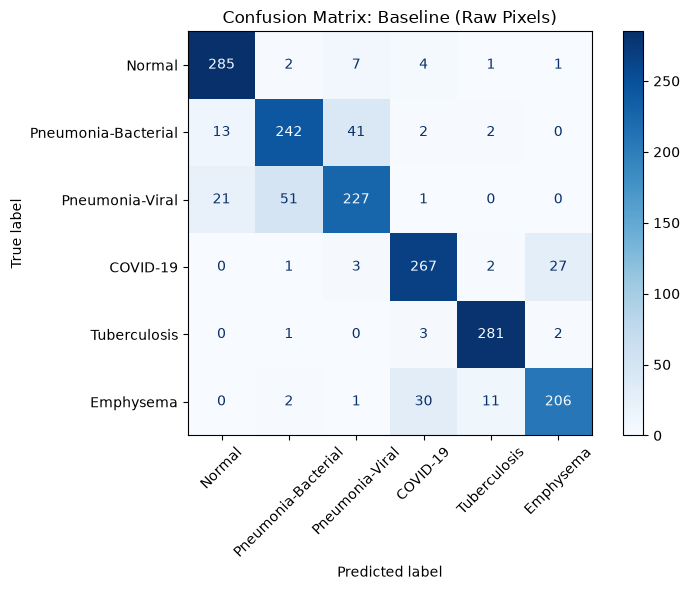

In [6]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===

[Combined Model] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.89      0.95      0.92       300
Pneumonia-Bacterial       0.82      0.82      0.82       300
    Pneumonia-Viral       0.83      0.77      0.80       300
           COVID-19       0.85      0.89      0.87       300
       Tuberculosis       0.96      0.98      0.97       287
          Emphysema       0.88      0.82      0.85       250

           accuracy                           0.87      1737
          macro avg       0.87      0.87      0.87      1737
       weighted avg       0.87      0.87      0.87      1737



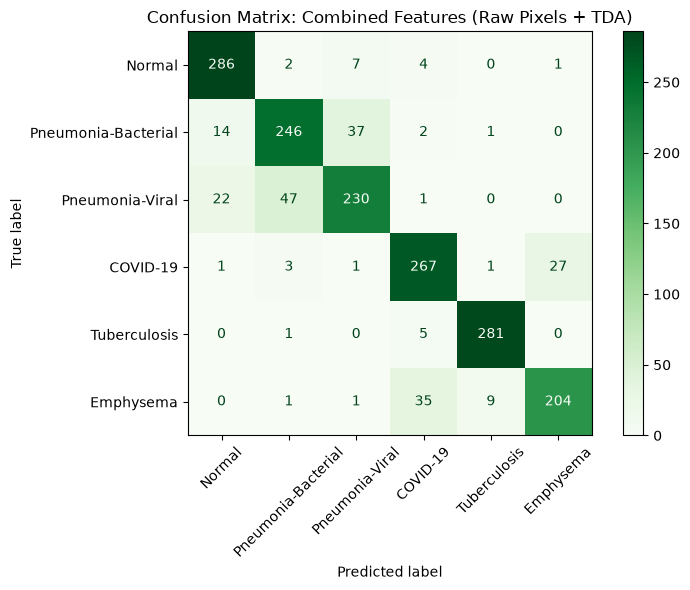

In [7]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()

VR 3D

In [ ]:
import cv2
import numpy as np
from ripser import ripser
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

def extract_features_3d_rips(image_path, target_size=(32, 32)):
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    img_resized = cv2.resize(img, target_size)
    z_intensity = img_resized / 255.0
    raw_pixels = z_intensity.flatten()
    
    try:
        x_coords = np.linspace(0, 1, target_size[1])
        y_coords = np.linspace(0, 1, target_size[0])
        xv, yv = np.meshgrid(x_coords, y_coords)
        
        point_cloud_3d = np.column_stack((xv.flatten(), yv.flatten(), raw_pixels))
        
        ripser_res = ripser(point_cloud_3d, maxdim=1)
        dgms = ripser_res['dgms']
        
        h0 = dgms[0][dgms[0][:, 1] != np.inf]
        h1 = dgms[1]
        
        if h0.shape[0] > 0:
            h0_ext = np.column_stack((h0, np.zeros(h0.shape[0])))
        else:
            h0_ext = np.empty((0, 3))
            
        if h1.shape[0] > 0:
            h1_ext = np.column_stack((h1, np.ones(h1.shape[0])))
        else:
            h1_ext = np.empty((0, 3))
            
        dgm_combined = np.vstack((h0_ext, h1_ext))
        gtda_diagrams = np.expand_dims(dgm_combined, axis=0)
        
        bc = BettiCurve(n_bins=50).fit_transform(gtda_diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(gtda_diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(gtda_diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(gtda_diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(gtda_diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda
    
def process_dataset_split_rips3d(split_name):
    """Scans directories and extracts features in parallel for a given split."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    results = Parallel(n_jobs=-1)(delayed(extract_features_3d_rips)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

In [ ]:
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split_rips3d('train')
X_val_raw, X_val_tda, y_val = process_dataset_split_rips3d('val')
X_test_raw, X_test_tda, y_test = process_dataset_split_rips3d('test')
print("Feature extraction finished successfully.")

Starting dataset-wide feature extraction...
[TRAIN] Found 14551 images. Processing...


In [ ]:
np.save("TRAIN_LANDSCAPES_VR3D_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_VR3D_y.npy", y_train)

np.save("VAL_LANDSCAPES_VR3D_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_VR3D_y.npy", y_val)

np.save("TEST_LANDSCAPES_VR3D_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_VR3D_y.npy", y_test)

=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===

[Baseline] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.88      0.94      0.91       300
Pneumonia-Bacterial       0.80      0.82      0.81       300
    Pneumonia-Viral       0.83      0.73      0.78       300
           COVID-19       0.84      0.89      0.86       300
       Tuberculosis       0.95      0.98      0.96       287
          Emphysema       0.86      0.80      0.83       250

           accuracy                           0.86      1737
          macro avg       0.86      0.86      0.86      1737
       weighted avg       0.86      0.86      0.86      1737



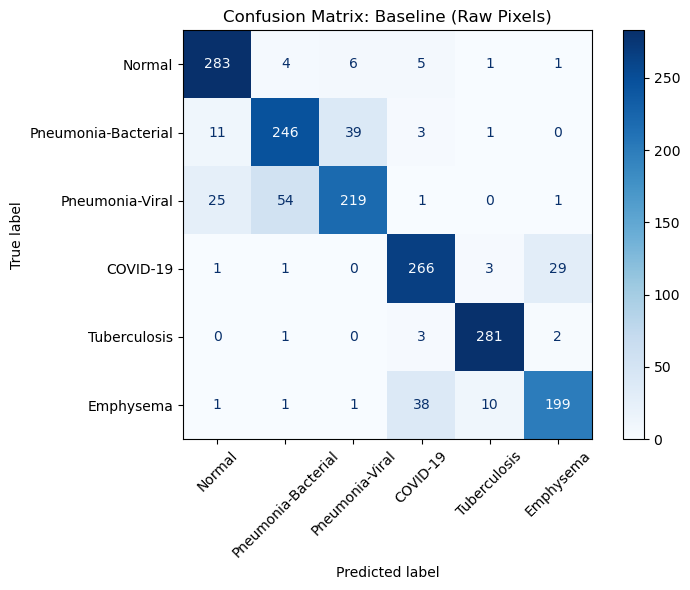

In [ ]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===

[Combined Model] Classification Report:
                     precision    recall  f1-score   support

             Normal       0.87      0.95      0.91       300
Pneumonia-Bacterial       0.79      0.81      0.80       300
    Pneumonia-Viral       0.82      0.72      0.77       300
           COVID-19       0.86      0.89      0.88       300
       Tuberculosis       0.96      0.99      0.98       287
          Emphysema       0.88      0.81      0.84       250

           accuracy                           0.86      1737
          macro avg       0.86      0.86      0.86      1737
       weighted avg       0.86      0.86      0.86      1737



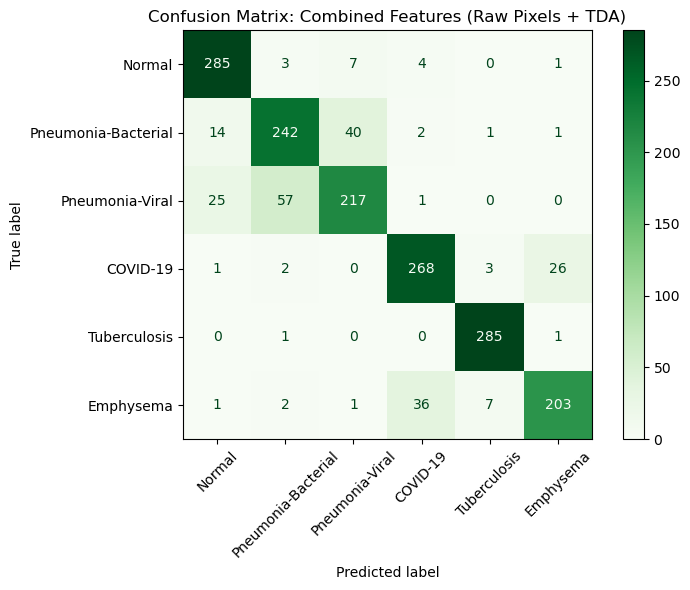

In [ ]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()

In [4]:
import cv2
import numpy as np
import subprocess
import tempfile
import os
from gtda.diagrams import BettiCurve, PersistenceLandscape, PersistenceEntropy, Amplitude

def extract_features_3d_rips_cpp(image_path, target_size=(32, 32)):
    # Feature dimensions: Betti (100) + Landscape (120) + Entropy (2) + Amp_W (2) + Amp_B (2) = 226
    default_raw = np.zeros(target_size[0] * target_size[1])
    default_tda = np.zeros(226)
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return default_raw, default_tda
        
    img_resized = cv2.resize(img, target_size)
    z_intensity = img_resized / 255.0
    raw_pixels = z_intensity.flatten()
    
    temp_filename = None
    try:
        x_coords = np.linspace(0, 1, target_size[1])
        y_coords = np.linspace(0, 1, target_size[0])
        xv, yv = np.meshgrid(x_coords, y_coords)
        
        point_cloud_3d = np.column_stack((xv.flatten(), yv.flatten(), raw_pixels))
        
        with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
            for pt in point_cloud_3d:
                f.write(f"{pt[0]} {pt[1]} {pt[2]}\n")
            temp_filename = f.name
            
        cmd = ["../../ripser/ripser", "--format", "point-cloud", "--dim", "1", temp_filename]
        
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        ripser_output = result.stdout
        
        h0_list, h1_list = [], []
        current_dim = -1
        
        for line in ripser_output.splitlines():
            line = line.strip()
            if line.startswith("persistence intervals in dim 0:"):
                current_dim = 0
            elif line.startswith("persistence intervals in dim 1:"):
                current_dim = 1
            elif line.startswith("["):
                clean_line = line.replace('[', '').replace(')', '').replace(' ', '')
                parts = clean_line.split(',')
                if len(parts) == 2:
                    birth = float(parts[0])
                    death_str = parts[1]
                    
                    if death_str == '' or 'inf' in death_str.lower() or '∞' in death_str:
                        death = np.inf
                    else:
                        death = float(death_str)
                        
                    if current_dim == 0:
                        h0_list.append([birth, death])
                    elif current_dim == 1:
                        h1_list.append([birth, death])
                        
        h0 = np.array(h0_list) if h0_list else np.empty((0, 2))
        h1 = np.array(h1_list) if h1_list else np.empty((0, 2))
        

        h0_filtered = h0[h0[:, 1] != np.inf] if h0.shape[0] > 0 else h0
        
        if h0_filtered.shape[0] > 0:
            h0_ext = np.column_stack((h0_filtered, np.zeros(h0_filtered.shape[0])))
        else:
            h0_ext = np.empty((0, 3))
            
        if h1.shape[0] > 0:
            h1_ext = np.column_stack((h1, np.ones(h1.shape[0])))
        else:
            h1_ext = np.empty((0, 3))
            
        dgm_combined = np.vstack((h0_ext, h1_ext))
        gtda_diagrams = np.expand_dims(dgm_combined, axis=0)
        
        bc = BettiCurve(n_bins=50).fit_transform(gtda_diagrams).flatten()                  # 100 features
        pl = PersistenceLandscape(n_layers=2, n_bins=30).fit_transform(gtda_diagrams).flatten() # 120 features
        pe = PersistenceEntropy(nan_fill_value=0.0).fit_transform(gtda_diagrams).flatten()  # 2 features
        amp_w = Amplitude(metric='wasserstein').fit_transform(gtda_diagrams).flatten()      # 2 features
        amp_b = Amplitude(metric='bottleneck').fit_transform(gtda_diagrams).flatten()       # 2 features
        
        tda_features = np.concatenate([bc, pl, pe, amp_w, amp_b])
        return raw_pixels, tda_features
        
    except subprocess.CalledProcessError as e:
        print(f"Ripser C++ execution error on {image_path}: {e.stderr}")
        return raw_pixels, default_tda
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return raw_pixels, default_tda
    finally:
        if temp_filename and os.path.exists(temp_filename):
            os.remove(temp_filename)

    
def process_dataset_split_rips3d_cpp(split_name):
    """Scans directories and extracts features in parallel for a given split."""
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(CLASSES):
        search_path = os.path.join(DATASET_DIR, split_name, class_name, "*.*")
        class_paths = glob.glob(search_path)
        class_paths = [p for p in class_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        image_paths.extend(class_paths)
        labels.extend([class_idx] * len(class_paths))
        
    print(f"[{split_name.upper()}] Found {len(image_paths)} images. Processing...")
    
    results = Parallel(n_jobs=-1)(delayed(extract_features_3d_rips_cpp)(path) for path in image_paths)
    
    X_raw = np.array([res[0] for res in results])
    X_tda = np.array([res[1] for res in results])
    y = np.array(labels)
    
    return X_raw, X_tda, y

In [5]:
print("Starting dataset-wide feature extraction...")
X_train_raw, X_train_tda, y_train = process_dataset_split_rips3d_cpp('train')
X_val_raw, X_val_tda, y_val = process_dataset_split_rips3d_cpp('val')
X_test_raw, X_test_tda, y_test = process_dataset_split_rips3d_cpp('test')
print("Feature extraction finished successfully.")

Starting dataset-wide feature extraction...
[TRAIN] Found 14551 images. Processing...


KeyboardInterrupt: 

In [ ]:
np.save("TRAIN_LANDSCAPES_VR3D_cpp_X.npy", X_train_tda)
np.save("TRAIN_LANDSCAPES_VR3D_cpp_y.npy", y_train)

np.save("VAL_LANDSCAPES_VR3D_cpp_X.npy", X_val_tda)
np.save("VAL_LANDSCAPES_VR3D_cpp_y.npy", y_val)

np.save("TEST_LANDSCAPES_VR3D_cpp_X.npy", X_test_tda)
np.save("TEST_LANDSCAPES_VR3D_cpp_y.npy", y_test)

In [ ]:
print("=== Training Baseline Model: Pure Random Forest (Raw Pixels) ===")
rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_raw, y_train)

y_pred_baseline = rf_baseline.predict(X_test_raw)
print("\n[Baseline] Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Blues'
)
ax.set_title("Confusion Matrix: Baseline (Raw Pixels)")
plt.tight_layout()
plt.show()

In [ ]:
print("=== Training Combined Model: Random Forest (Raw Pixels + TDA Features) ===")
X_train_combined = np.hstack((X_train_raw, X_train_tda))
X_test_combined = np.hstack((X_test_raw, X_test_tda))

rf_combined = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)

y_pred_combined = rf_combined.predict(X_test_combined)
print("\n[Combined Model] Classification Report:")
print(classification_report(y_test, y_pred_combined, target_names=CLASSES))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_combined, display_labels=CLASSES, xticks_rotation=45, ax=ax, cmap='Greens'
)
ax.set_title("Confusion Matrix: Combined Features (Raw Pixels + TDA)")
plt.tight_layout()
plt.show()